In [1]:
# read data yearky in pickle file
import pickle
import sys
import os
import numpy as np
maindir = os.getcwd()
sys.path.append(maindir+"/src")


# data = pickle.load('data_yearly.pickle')

with open('data_yearly.pickle', 'rb') as f:
    data = pickle.load(f)

In [7]:
data_anomaly_yearly = data['dic_data_yearly']
data_forced_response_yearly = data['dic_forced_response_yearly']

In [8]:
# compute the variance of anomaly per climate model and standardize
means_yearly = {}
vars_yearly = {}
vars = {}
means = {}

# for each model, compute the variance of the anomaly
for dir in list(data_anomaly_yearly.keys()):
    print(f'Computing variance for {dir}')
    # means_yearly[dir] = np.nanmean(dic_data_yearly[dir], axis=0)
    means_yearly[dir] =  np.zeros((data_anomaly_yearly[dir].shape[1], data_anomaly_yearly[dir].shape[2], data_anomaly_yearly[dir].shape[3]), dtype=np.float32)
    vars_yearly[dir] = np.nanvar(data_anomaly_yearly[dir], axis=0)
    vars[dir] = np.nanvar(data_anomaly_yearly[dir], axis=0)
    means[dir] = np.zeros((data_anomaly_yearly[dir].shape[1], data_anomaly_yearly[dir].shape[2], data_anomaly_yearly[dir].shape[3]), dtype=np.float32)

Computing variance for CESM2
Computing variance for CanESM5
Computing variance for MIROC-ES2L
Computing variance for MIROC6
Computing variance for MPI-ESM1-2-LR


In [9]:
import torch

def normalize_data(data, means, vars):
    """Normalize the data with respect to the monthly mean and the variance of the anomaly.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           means: numpy array of shape (runs, latitude, longitude)
           vars: numpy array of shape (runs, latitude, longitude)
       Return:
           normalized_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    normalized_data = {}
    for idx,key in enumerate(data.keys()):
        normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])
    return normalized_data

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,x[m].shape[2]*x[m].shape[3])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,x[m].shape[2]*x[m].shape[3])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,x[m].shape[2]*x[m].shape[3]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,x[m].shape[2]*x[m].shape[3]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],x[m].shape[2]*x[m].shape[3])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],x[m].shape[2]*x[m].shape[3])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [10]:
dic_data_yearly_tmp = normalize_data(data_anomaly_yearly, means_yearly, vars_yearly)
dic_forced_response_yearly_tmp= normalize_data(data_forced_response_yearly, means_yearly, vars_yearly)

In [11]:
x_train_yearly, y_train_yearly  = merge_training_data(data_anomaly_yearly,data_forced_response_yearly,dtype=torch.float32)

  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])


In [12]:
from algorithms import ridge_regression, ridge_regression_low_rank
# proximal_algorithm_ridge_trace_penalty,train_trace_norm_ridge

# penalty parameters
lambda_tmp = 5000.0


# ridge regression
w_ridge = ridge_regression(x_train_yearly, y_train_yearly, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)
# w_ridge_low_rank = ridge_regression_low_rank(x_train_yearly, y_train_yearly, rank=5, lambda_=lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_train_yearly@w_ridge,full_matrices=False)

Loss function:  524860.5625


In [14]:
# define the rank
rank = 5

w_ridge_low_rank = w_ridge @ V[:rank,:].T @ V[:rank,:]

In [15]:
x_test_yearly = torch.from_numpy(data['x_test_yearly']).to(torch.float32).reshape(data['x_test_yearly'].shape[0],data['x_test_yearly'].shape[1],data['x_test_yearly'].shape[2]*data['x_test_yearly'].shape[3])
y_test_yearly = torch.from_numpy(data['y_test_yearly']).to(torch.float32).reshape(data['x_test_yearly'].shape[0],data['x_test_yearly'].shape[1],data['x_test_yearly'].shape[2]*data['x_test_yearly'].shape[3])

In [16]:
anomaly_test = data['x_test_yearly'][:-1,:,:,:]
forced_response_test = data['y_test_yearly'][:-1,:,:,:]

In [17]:
# Evaluate the model on test data
y_pred = x_test_yearly @ w_ridge
y_pred_low_rank = x_test_yearly @ w_ridge_low_rank


# Compute the mean squared error
rmse = torch.sqrt(torch.mean((y_pred - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.mean((y_pred_low_rank - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE: {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')

  MSE: [0.23408726 0.4491907  0.55577177 0.31414    0.45788807 0.24112941
 0.30960974 0.23573107 0.3058776  0.52627414]
  MSE trace norm: [0.23110066 0.445197   0.55550396 0.3100921  0.4585886  0.2381834
 0.30627918 0.2362746  0.30466568 0.52367544]


In [20]:
## code to generate corrupted data for each climate model
def generate_corrupted_data(data, noise_level=0.1, n_samples=10):
    """Generate corrupted data by adding Gaussian noise to the original data.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           noise_level: standard deviation of the Gaussian noise
       Return:
           corrupted_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    noise = np.random.normal(0, noise_level, (n_samples, data.shape[1],data.shape[2], data.shape[3]))
    print(f'  noise shape: {noise.shape}')

    # select a random sample from the training set using an index
    idx_sample = np.random.randint(0, data.shape[0], size=n_samples)

    corrupted_data = data[idx_sample,:,:,:] + noise
    return idx_sample, corrupted_data


n_samples = 10
gamma = 0.75

# Generate corrupted data for each climate model
idx_corrupted_samples = {}
corrupted_data_yearly = {}
corrupted_data_yearly_forced_response = {}
for dir in list(data_anomaly_yearly.keys()):
    print(f'Generating corrupted data for {dir}')
    idx_corrupted_samples[dir], corrupted_data_yearly[dir] = generate_corrupted_data(data_anomaly_yearly[dir], noise_level= gamma*vars_yearly[dir], n_samples=n_samples)
    # print(f'  corrupted data shape: { dic_forced_response_yearly[dir].shape}')
    corrupted_data_yearly_forced_response[dir] = np.repeat(np.expand_dims(data_forced_response_yearly[dir][0,:,:,:],axis=0),axis=0, repeats=n_samples)
    print(f'  corrupted forced response data shape: {corrupted_data_yearly_forced_response[dir].shape}')

# Merge the corrupted data into a single training set
x_train_corrupted, y_train_corrupted = merge_training_data(corrupted_data_yearly, corrupted_data_yearly_forced_response, dtype=torch.float32)

Generating corrupted data for CESM2
  noise shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
Generating corrupted data for CanESM5
  noise shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
Generating corrupted data for MIROC-ES2L
  noise shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
Generating corrupted data for MIROC6
  noise shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
Generating corrupted data for MPI-ESM1-2-LR
  noise shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
  x_train shape: torch.Size([2210, 10368])
  x_train shape: torch.Size([4420, 10368])
  x_train shape: torch.Size([6630, 10368])
  x_train shape: torch.Size([8840, 10368])
  x_train shape: torch.Size([11050, 10368])


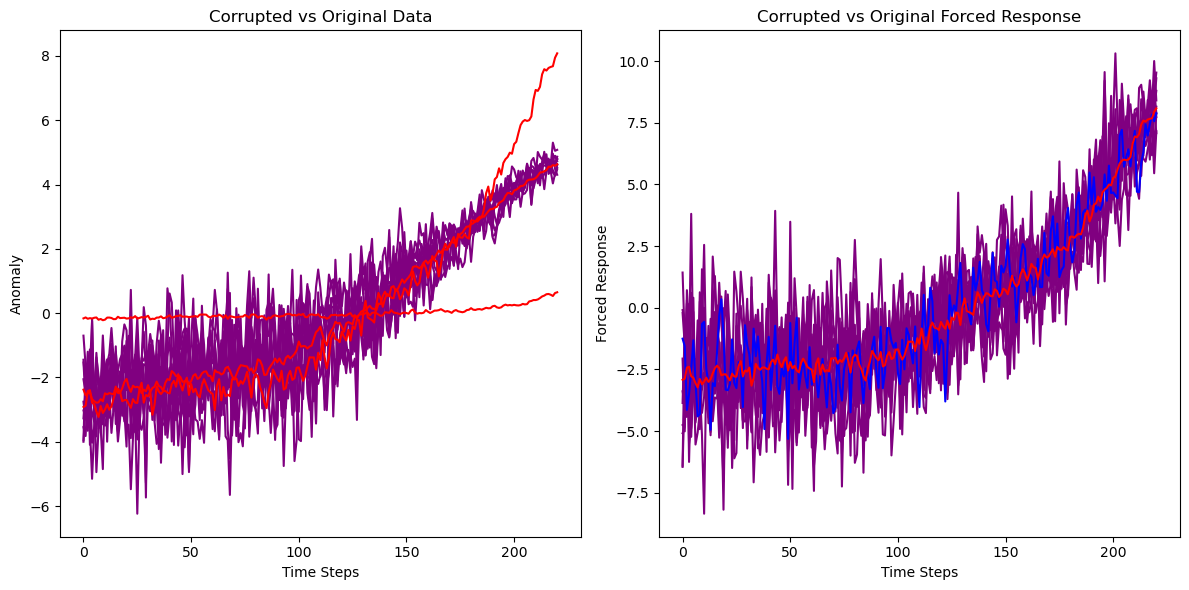

In [28]:
import matplotlib.pyplot as plt


# plot the corrupted data vs the original data for each climate model
model_name0 = 'CESM2'
model_name1 = 'MIROC6'
model_name2 = 'CanESM5'
idx_run = 3
idx_lat = 10
idx_lon = 10
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for i in range(n_samples):
    plt.plot(corrupted_data_yearly[model_name0][i,:,idx_lat,idx_lon], label='Corrupted Data', color='purple')
# plt.plot(corrupted_data_yearly[model_name][idx_run+1,:,idx_lat,idx_lon], label='Corrupted Data', color='green')
# plt.plot(data_anomaly_yearly[model_name][idx_corrupted_samples[model_name][idx_run],:,idx_lat,idx_lon], label='Original Data', color='blue')
plt.plot(data_forced_response_yearly[model_name0][0,:,idx_lat,idx_lon], label='Forced response', color='red')
plt.plot(data_forced_response_yearly[model_name1][0,:,idx_lat,idx_lon], label='Forced response', color='red')
plt.plot(data_forced_response_yearly[model_name2][0,:,idx_lat,idx_lon], label='Forced response', color='red')
# plt.plot(range(221-73,221),data['y_test_yearly'][2,:,idx_lat,idx_lon], label='Test Data', color='green')
plt.title('Corrupted vs Original Data')
plt.xlabel('Time Steps')
plt.ylabel('Anomaly')
# plt.legend()

model_name = 'CanESM5'

plt.subplot(1, 2, 2)
# plt.plot(corrupted_data_yearly[model_name][idx_run,:,idx_lat,idx_lon], label='Corrupted Data', color='purple')
for i in range(n_samples):
    plt.plot(corrupted_data_yearly[model_name][i,:,idx_lat,idx_lon], label='Corrupted Data', color='purple')
plt.plot(data_anomaly_yearly[model_name][idx_corrupted_samples[model_name][idx_run],:,idx_lat,idx_lon], label='Original Data', color='blue')
plt.plot(data_forced_response_yearly[model_name][idx_corrupted_samples[model_name][idx_run],:,idx_lat,idx_lon], label='Forced Response', color='red')
# plt.plot(data['y_test_yearly'][:,:,idx_lat,idx_lon], label='Test Data', color='green')
# plt.plot(range(221-73,221),data['y_test_yearly'][2,:,idx_lat,idx_lon], label='Test Data', color='green')
plt.title('Corrupted vs Original Forced Response')
plt.xlabel('Time Steps')
plt.ylabel('Forced Response')
# plt.legend()


plt.tight_layout()
plt.show()



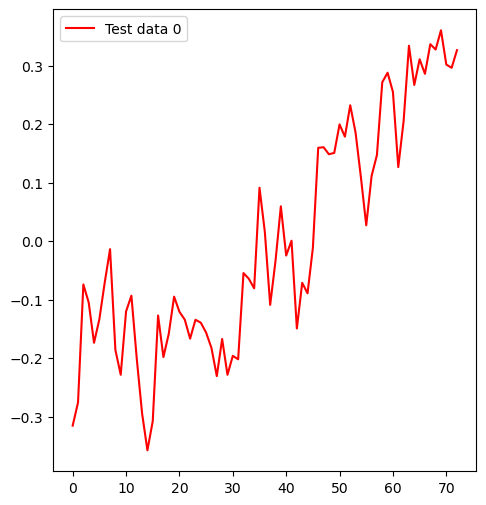

In [29]:
# plot the test data at the same location 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
# for i in range(forced_response_test.shape[0]):
plt.plot(forced_response_test[0,:,idx_lat,idx_lon], label=f'Test data {0}', color='red')
# plt.plot(forced_response_test[1,:,idx_lat,idx_lon], label=f'Test data {1}', color='red')
# plt.plot(forced_response_test[2,:,idx_lat,idx_lon], label=f'Test data {2}', color='red')
# plt.plot(forced_response_test[3,:,idx_lat,idx_lon], label=f'Test data {2}', color='red',alpha=i/forced_response_test.shape[0])
# plt.plot(forced_response_test[4,:,idx_lat,idx_lon], label=f'Test data {2}', color='red',alpha=i/forced_response_test.shape[0])
# plt.plot(forced_response_test[5,:,idx_lat,idx_lon], label=f'Test data {2}', color='red',alpha=i/forced_response_test.shape[0])
# plt.plot(forced_response_test[6,:,idx_lat,idx_lon], label=f'Test data {2}', color='red',alpha=i/forced_response_test.shape[0])
# plt.plot(forced_response_test[7,:,idx_lat,idx_lon], label=f'Test data {2}', color='red',alpha=i/forced_response_test.shape[0])
# plt.plot(forced_response_test[8,:,idx_lat,idx_lon], label=f'Test data {2}', color='red',alpha=i/forced_response_test.shape[0])
    
plt.legend()
plt.show()
# plt.plot(y_test_yearly[idx_run,:,idx_lat,idx_lon], label='Test Data', color='blue')


In [22]:
# merge the corrupted data and the original data
x_train_combined = torch.cat([x_train_yearly, x_train_corrupted], dim=0)
y_train_combined = torch.cat([y_train_yearly, y_train_corrupted], dim=0)

In [23]:
# penalty parameters
lambda_tmp = 15000.0

# ridge regression
w_ridge_corrupted = ridge_regression(x_train_combined, y_train_combined, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_train_combined@w_ridge_corrupted,full_matrices=False)

Loss function:  1140572.625


In [24]:
# define the rank
rank = 2

w_ridge_low_rank_corrupted = w_ridge_corrupted @ V[:rank,:].T@V[:rank,:]

In [25]:
# Evaluate the model on test data
y_pred_tmp = x_test_yearly @ w_ridge_corrupted
y_pred_low_rank_tmp = x_test_yearly @ w_ridge_low_rank_corrupted


# Compute the mean squared error
rmse_tmp = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_tmp = torch.sqrt(torch.mean((y_pred_low_rank_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE : {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')

print(f'  MSE with corrupted data: {rmse_tmp}')
print(f'  MSE trace norm with corrupted data: {rmse_low_rank_tmp}')

  MSE : [0.23408726 0.4491907  0.55577177 0.31414    0.45788807 0.24112941
 0.30960974 0.23573107 0.3058776  0.52627414]
  MSE trace norm: [0.23110066 0.445197   0.55550396 0.3100921  0.4585886  0.2381834
 0.30627918 0.2362746  0.30466568 0.52367544]
  MSE with corrupted data: [0.23514298 0.44655618 0.5543408  0.31722265 0.476511   0.2445669
 0.30923623 0.2402583  0.31009018 0.5291429 ]
  MSE trace norm with corrupted data: [0.23087803 0.41536993 0.5487773  0.30769417 0.46516916 0.23952545
 0.29264712 0.24259225 0.3031562  0.5222484 ]


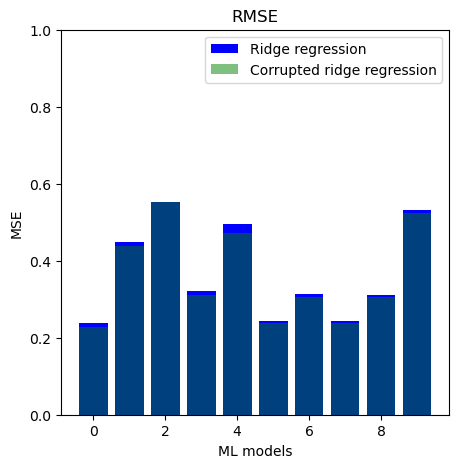

In [43]:
plt.figure(figsize=(5, 5))
plt.bar(range(rmse.shape[0]), rmse, color='blue', label='Ridge regression')
plt.bar(range(rmse.shape[0]), rmse_low_rank_tmp, color='green', label='Corrupted ridge regression', alpha=0.5)
plt.title('RMSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

In [27]:
# evaluate the model on normalized test data (this is weird but let's do it)
y_pred_tmp = x_test_yearly @ w_ridge_corrupted
# Compute the mean squared error
rmse_tmp = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
print(f'  MSE with normalized test data: {rmse_tmp}')
print(f'  MSE with unnormalized test data: {rmse}')

  MSE with normalized test data: [0.23514298 0.44655618 0.5543408  0.31722265 0.476511   0.2445669
 0.30923623 0.2402583  0.31009018 0.5291429 ]
  MSE with unnormalized test data: [0.23408726 0.4491907  0.55577177 0.31414    0.45788807 0.24112941
 0.30960974 0.23573107 0.3058776  0.52627414]


In [ ]:
lambda_tmp =15000.0
w_ridge_corrupted_tmp = {}
w_ridge_low_rank_corrupted_tmp = {}

# training for corrupted data of each climate model
for dir in list(corrupted_data_yearly.keys()):
    print(f'Computing ridge regression for {dir}')

    # merge the corrupted data  and the original data for this specific model 
    x_train_yearly_tmp = torch.from_numpy(data_anomaly_yearly[dir]).to(torch.float32).reshape(data_anomaly_yearly[dir].shape[0]*data_anomaly_yearly[dir].shape[1],data_anomaly_yearly[dir].shape[2]*data_anomaly_yearly[dir].shape[3])    
    y_train_yearly_tmp = torch.from_numpy(data_forced_response_yearly[dir]).to(torch.float32).reshape(data_forced_response_yearly[dir].shape[0]*data_forced_response_yearly[dir].shape[1],data_forced_response_yearly[dir].shape[2]*data_forced_response_yearly[dir].shape[3])

    x_train_tmp = torch.from_numpy(corrupted_data_yearly[dir]).to(torch.float32).reshape(corrupted_data_yearly[dir].shape[0]*corrupted_data_yearly[dir].shape[1],corrupted_data_yearly[dir].shape[2]*corrupted_data_yearly[dir].shape[3])
    y_train_tmp = torch.from_numpy(corrupted_data_yearly_forced_response[dir]).to(torch.float32).reshape(corrupted_data_yearly_forced_response[dir].shape[0]*corrupted_data_yearly_forced_response[dir].shape[1],corrupted_data_yearly_forced_response[dir].shape[2]*corrupted_data_yearly_forced_response[dir].shape[3])


    # merge the training data 
    x_train_combined = torch.cat([x_train_yearly_tmp, x_train_tmp], dim=0)
    y_train_combined = torch.cat([y_train_yearly_tmp, y_train_tmp], dim=0)
    print(f'  x_train_combined shape: {x_train_combined.shape}')
    print(f'  y_train_combined shape: {y_train_combined.shape}')

    w_ridge_corrupted_tmp[dir] = ridge_regression(x_train_combined, y_train_combined, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)
    
    # low rank regression
    U,S,V = torch.linalg.svd(x_train_combined@w_ridge_corrupted_tmp[dir],full_matrices=False)

    # # define the rank
    rank = 10

    w_ridge_low_rank_corrupted_tmp[dir] = w_ridge_corrupted_tmp @ V[:rank,:].T@V[:rank,:]

    # Evaluate the model on test data
    y_pred_tmp = x_test_yearly @ w_ridge_corrupted_tmp[dir]
    # y_pred_low_rank_tmp = x_test_yearly @ w_ridge_low_rank_corrupted_tmp

    # Compute the mean squared error
    rmse = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

    print(f'  MSE : {rmse}')
    

Computing ridge regression for CESM2
  x_train_combined shape: torch.Size([22100, 10368])
  y_train_combined shape: torch.Size([22100, 10368])
Loss function:  3919447.75
  MSE : [0.21764041 0.29807732 0.6840253  0.30213162 0.26905882 0.23205963
 0.33310574 0.2288674  0.24685426 0.43203902]
Computing ridge regression for CanESM5
  x_train_combined shape: torch.Size([16575, 10368])
  y_train_combined shape: torch.Size([16575, 10368])
Loss function:  6998757.5
  MSE : [0.23233812 0.4573622  0.5559076  0.30337083 0.51640207 0.24831784
 0.320896   0.26617298 0.30665356 0.46131238]
Computing ridge regression for MIROC-ES2L
  x_train_combined shape: torch.Size([17680, 10368])
  y_train_combined shape: torch.Size([17680, 10368])
Loss function:  3321496.25
  MSE : [0.2256307  0.35752714 0.5959968  0.2775377  0.39847875 0.25305822
 0.28951737 0.23974264 0.3112119  0.47169617]
Computing ridge regression for MIROC6
  x_train_combined shape: torch.Size([22100, 10368])
  y_train_combined shape: torc